<a href="https://colab.research.google.com/github/dnanaat/PCVK_Genap_2026/blob/main/Week6_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


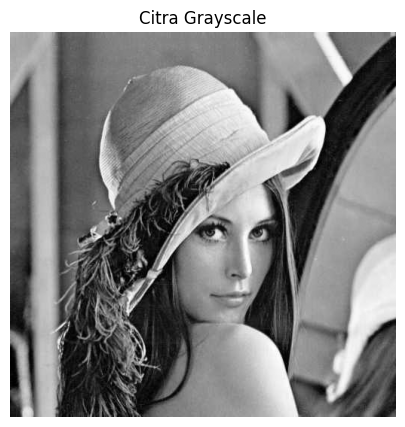

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

# FUNGSI MENAMPILKAN GAMBAR

def show_image(title, image, cmap=None):
    plt.figure(figsize=(7, 5))

    if len(image.shape) == 2:
        plt.imshow(image, cmap=cmap if cmap else "gray")
    else:
        plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis("off")
    plt.show()


# LOAD IMAGE

image_path = "/content/drive/MyDrive/PCVK/lena.jpeg"

img = cv.imread(image_path)

if img is None:
    raise FileNotFoundError(
        f"Gambar tidak ditemukan: {image_path}"
    )

# Ubah menjadi grayscale
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

show_image("Citra Grayscale", img_gray, "gray")


# FUNGSI KONVOLUSI TANPA LIBRARY KONVOLUSI

def convolution2d(image, kernel, padding=1, stride=1):

    image = image.astype(np.float32)
    kernel = np.array(kernel, dtype=np.float32)

    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape

    # Padding
    padded_image = np.pad(
        image,
        (
            (padding, padding),
            (padding, padding)
        ),
        mode="constant",
        constant_values=0
    )

    output_height = (
        (image_height + 2 * padding - kernel_height)
        // stride
    ) + 1

    output_width = (
        (image_width + 2 * padding - kernel_width)
        // stride
    ) + 1

    output = np.zeros(
        (output_height, output_width),
        dtype=np.float32
    )

    # Proses konvolusi
    for y in range(0, output_height):

        for x in range(0, output_width):

            y_start = y * stride
            x_start = x * stride

            region = padded_image[
                y_start:y_start + kernel_height,
                x_start:x_start + kernel_width
            ]

            output[y, x] = np.sum(region * kernel)

    # Batasi nilai 0-255
    output = np.clip(output, 0, 255)

    return output.astype(np.uint8)

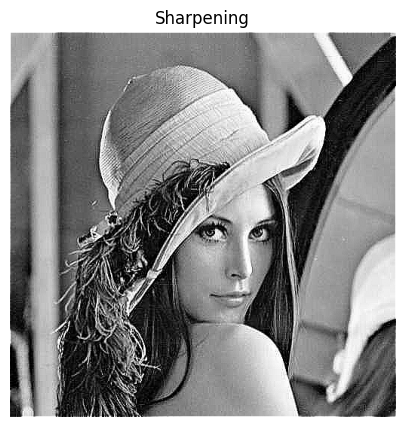

In [11]:
# SHARPENING

kernel_sharpen = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
])

sharpen = convolution2d(
    img_gray,
    kernel_sharpen,
    padding=1
)

show_image(
    "Sharpening",
    sharpen,
    "gray"
)

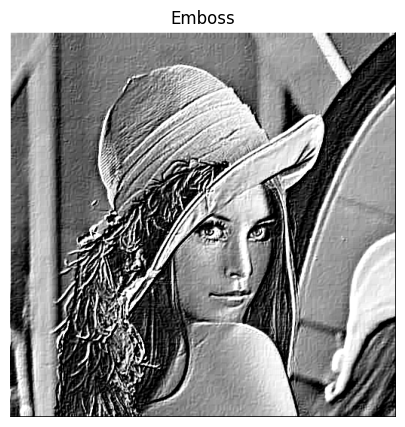

In [12]:
# EMBOSS

kernel_emboss = np.array([
    [-2, -1, 0],
    [-1,  1, 1],
    [ 0,  1, 2]
])

emboss = convolution2d(
    img_gray,
    kernel_emboss,
    padding=1
)

show_image(
    "Emboss",
    emboss,
    "gray"
)

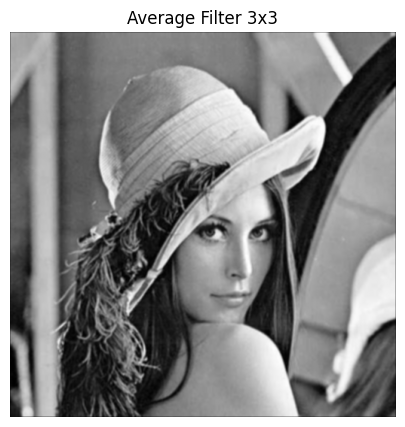

In [13]:
# AVERAGE FILTER

kernel_average = np.ones((3, 3), dtype=np.float32) / 9

average = convolution2d(
    img_gray,
    kernel_average,
    padding=1
)

show_image(
    "Average Filter 3x3",
    average,
    "gray"
)

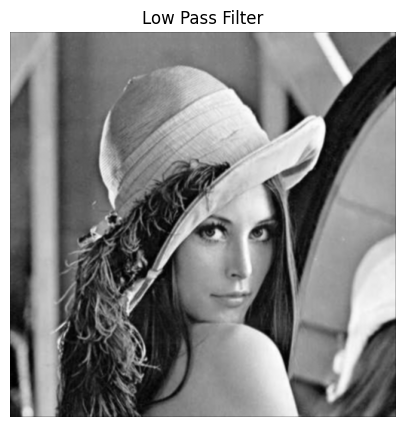

In [14]:
# LOW PASS FILTER

kernel_lowpass = np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
], dtype=np.float32) / 12

lowpass = convolution2d(
    img_gray,
    kernel_lowpass,
    padding=1
)

show_image(
    "Low Pass Filter",
    lowpass,
    "gray"
)

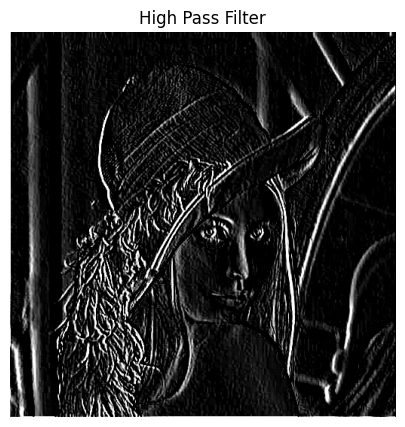

In [15]:
# HIGH PASS FILTER

kernel_highpass = np.array([
    [-1, 0, 1],
    [-1, 0, 3],
    [-3, 0, 1]
])

highpass = convolution2d(
    img_gray,
    kernel_highpass,
    padding=1
)

show_image(
    "High Pass Filter",
    highpass,
    "gray"
)

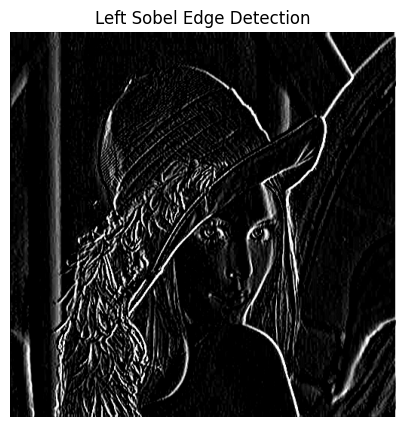

In [16]:
# LEFT SOBEL EDGE DETECTION

kernel_left_sobel = np.array([
    [1,  0, -1],
    [2,  0, -2],
    [1,  0, -1]
])

left_sobel = convolution2d(
    img_gray,
    kernel_left_sobel,
    padding=1
)

show_image(
    "Left Sobel Edge Detection",
    left_sobel,
    "gray"
)

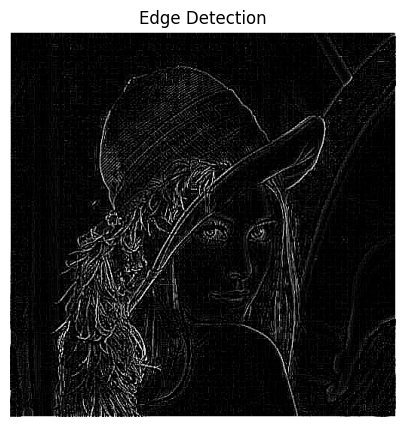

In [17]:
# EDGE DETECTION

kernel_edge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

edge = convolution2d(
    img_gray,
    kernel_edge,
    padding=1
)

show_image(
    "Edge Detection",
    edge,
    "gray"
)

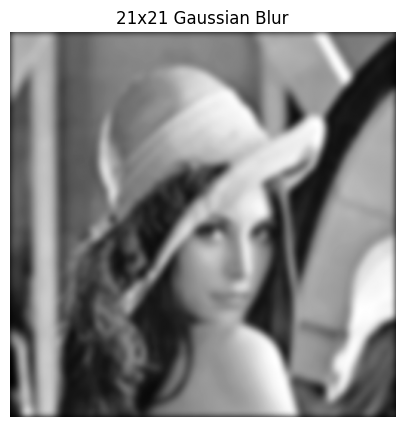

In [19]:
# 21x21 GAUSSIAN BLUR

kernel_size = 21

sigma = math.sqrt(kernel_size)

gaussian_kernel = cv.getGaussianKernel(
    kernel_size,
    sigma
)

gauss_kernel = (
    gaussian_kernel @ gaussian_kernel.transpose()
)

gaussian_21 = convolution2d(
    img_gray,
    gauss_kernel,
    padding=kernel_size // 2
)

show_image(
    "21x21 Gaussian Blur",
    gaussian_21,
    "gray"
)

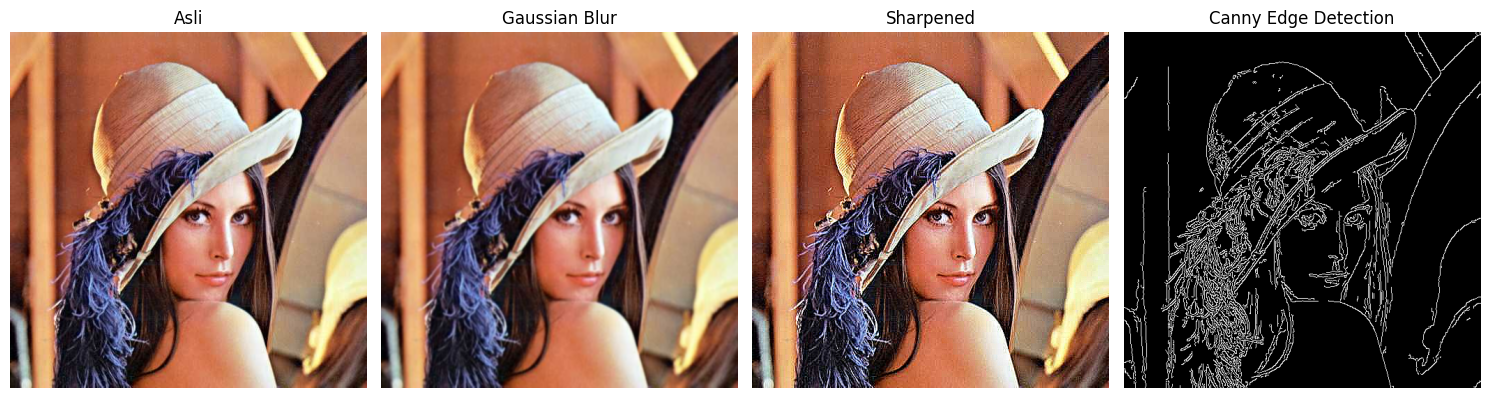

In [20]:
# PERCOBAAN 1
# Gaussian Blur, Sharpen, Canny

# Gaussian Blur
blur = cv.GaussianBlur(
    img,
    (7, 7),
    1
)

# Sharpen menggunakan filter2D
kernel_sharpen_rgb = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpen_rgb = cv.filter2D(
    img,
    -1,
    kernel_sharpen_rgb
)

# Canny
edges = cv.Canny(
    img,
    100,
    200
)

# Tampilkan
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Asli")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(cv.cvtColor(blur, cv.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(cv.cvtColor(sharpen_rgb, cv.COLOR_BGR2RGB))
plt.title("Sharpened")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

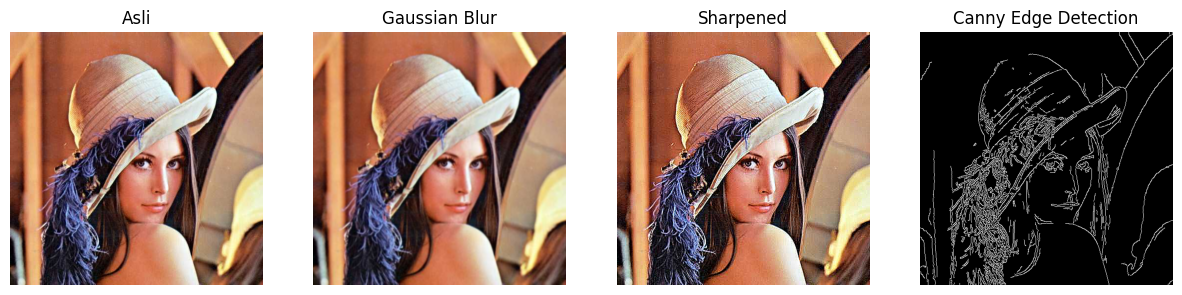

In [23]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# Baca gambar
img = cv.imread("/content/drive/MyDrive/PCVK/lena.jpeg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Operasi citra
blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

# Tampilkan hasil
show_side_by_side(
    [img, blur, sharpened, edges],
    ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"]
)


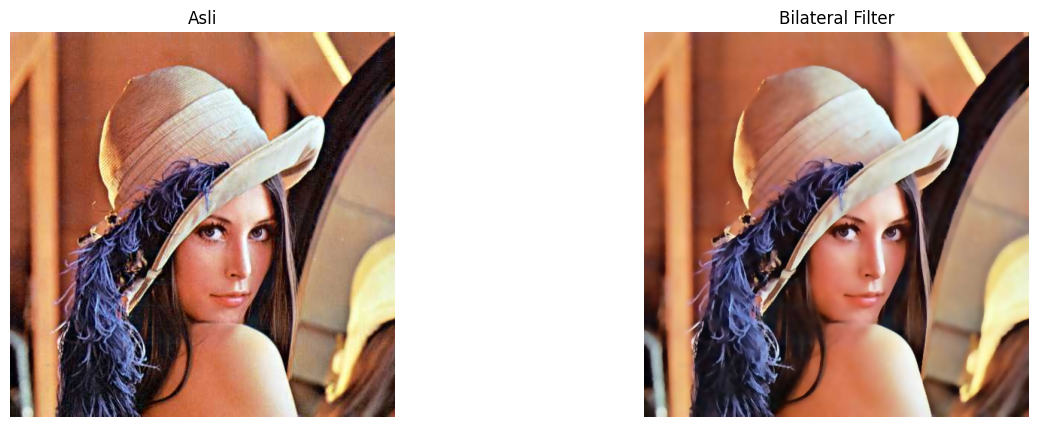

In [25]:
# PERCOBAAN 2
# BILATERAL FILTER

bilateral = cv.bilateralFilter(img, 9, 75, 75)

show_side_by_side([img, bilateral],["Asli","Bilateral Filter"]
)

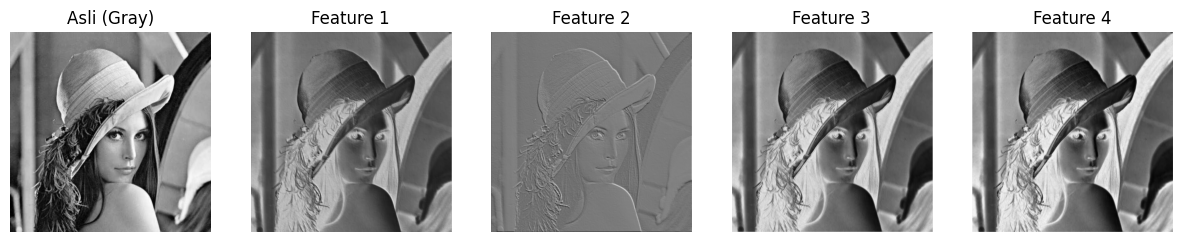

In [27]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Definisi CNN sederhana
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

# Inisialisasi model
model = SimpleCNN()

# Ubah gambar grayscale ke tensor (pastikan img_gray sudah ada dari kode sebelumnya)
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Jalankan CNN untuk mendapatkan feature maps
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side(
    [img_gray] + feature_maps,
    ['Asli (Gray)'] + [f'Feature {i+1}' for i in range(len(feature_maps))]
)

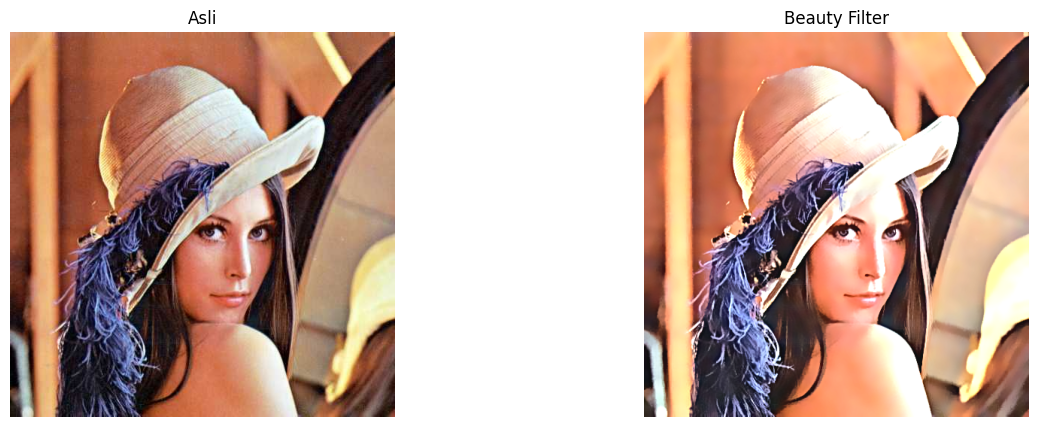

In [30]:
# PERCOBAAN 4
# BEAUTY FILTER

# Step 1: smoothing
smooth = cv.bilateralFilter(img,15,50,50)

# Step 2: unsharp masking
gaussian = cv.GaussianBlur(smooth,(0, 0),3)

sharpened = cv.addWeighted(smooth,1.5,gaussian,-0.5,0)

# Step 3: brightness dan contrast
alpha = 1.2
beta = 15

beauty = cv.convertScaleAbs(sharpened,alpha=alpha,beta=beta)

show_side_by_side([img,beauty],["Asli","Beauty Filter"])

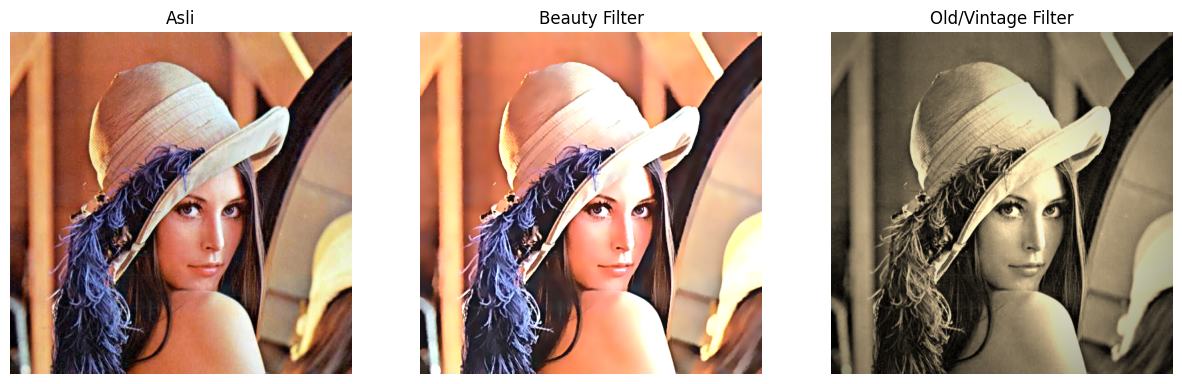

In [32]:
# VINTAGE FILTER

sepia_kernel = np.array([
    [0.272, 0.534, 0.131],
    [0.349, 0.686, 0.168],
    [0.393, 0.769, 0.189]
])

sepia = cv.transform(img,sepia_kernel)

sepia = np.clip(sepia,0,255).astype(np.uint8)

# Vignette
rows, cols = img.shape[:2]

kernel_x = cv.getGaussianKernel(cols,cols * 0.6)

kernel_y = cv.getGaussianKernel(rows,rows * 0.6)

kernel = kernel_y @ kernel_x.T

mask = kernel / kernel.max()

vignette = sepia.copy()

for i in range(3):

    vignette[:, :, i] = (
        vignette[:, :, i] * mask
    )


show_side_by_side([img,beauty,vignette],["Asli","Beauty Filter","Old/Vintage Filter"])

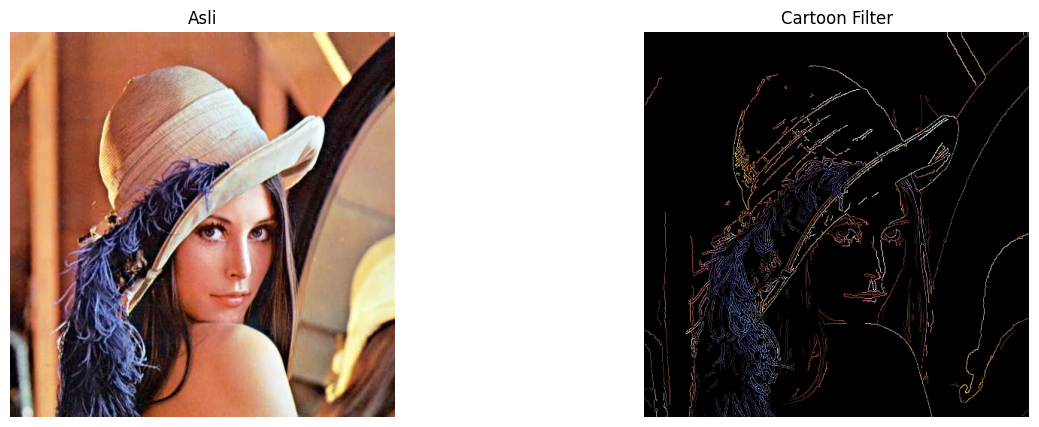

In [33]:
# PERCOBAAN 5 / TUGAS KREASI
# CARTOON FILTER

def kartun(image):

    # 1. Penghalusan warna
    smooth = cv.bilateralFilter(image,9,75,75)

    # 2. Grayscale
    gray = cv.cvtColor(image,cv.COLOR_BGR2GRAY)

    # 3. Canny Edge
    edges = cv.Canny(gray,100,200)

    # 4. Threshold
    edges = cv.threshold(edges,100,255,cv.THRESH_BINARY)[1]

    # 5. Ubah edge menjadi 3 channel
    edges = cv.cvtColor(edges,cv.COLOR_GRAY2BGR)

    # 6. Kombinasikan warna dengan edge
    cartoon = cv.bitwise_and(smooth,edges)

    return cartoon

cartoon = kartun(img)

show_side_by_side([img,cartoon],["Asli","Cartoon Filter"])

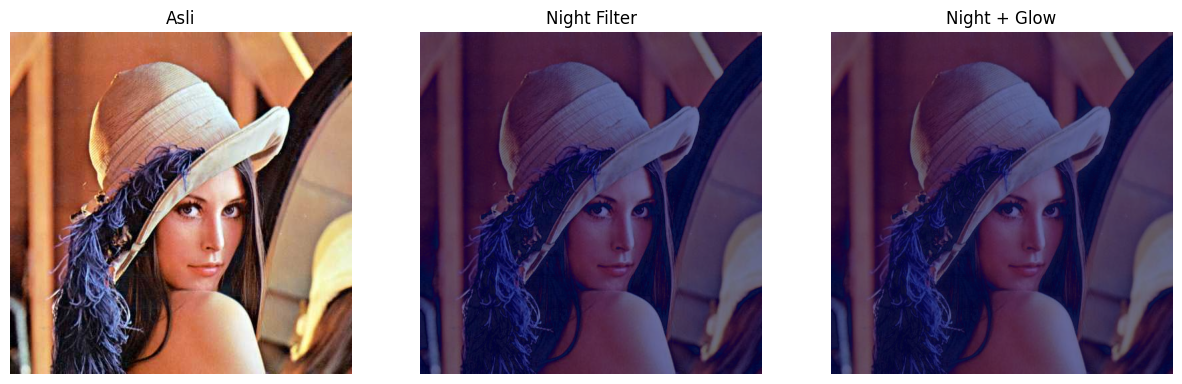

In [34]:
# PERCOBAAN 6
# NIGHT FILTER

# Kurangi brightness
night = cv.convertScaleAbs(img,alpha=0.5,beta=-20)

# Beri nuansa biru
blue_tint = np.zeros_like(night)

blue_tint[:, :, 0] = 50

night = cv.add(night,blue_tint)

# Glow
blur_night = cv.GaussianBlur(night,(0, 0),5)

night_glow = cv.addWeighted(night,0.8,blur_night,0.2,0)

show_side_by_side([img,night,night_glow],["Asli","Night Filter","Night + Glow"])

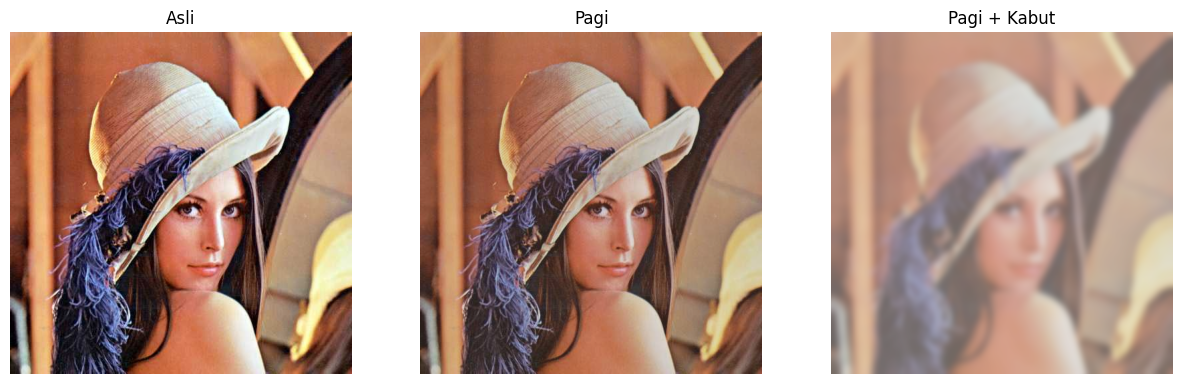

In [35]:
# PERCOBAAN 7
# MORNING + FOG

# Step 1: Kurangi kontras dan cerahkan
alpha = 0.9
beta = 20

morning = cv.convertScaleAbs(img,alpha=alpha,beta=beta)

# Step 2: Tambahkan warna hangat
warm_tint = np.full_like(morning,(40, 70, 120))

morning = cv.addWeighted(morning,0.8,warm_tint,0.2,0)


# Step 3: Fog menggunakan Gaussian
kernel_size = 31

kernel = cv.getGaussianKernel(kernel_size,-1)

kernel = kernel @ kernel.T

fog = cv.filter2D(morning,-1,kernel)

# Tambahkan lapisan putih
white_layer = np.full_like(fog,255)

fog = cv.addWeighted(fog,0.7,white_layer,0.3,0)

show_side_by_side([img,morning,fog],["Asli","Pagi","Pagi + Kabut"])